In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Data Understanding

In [2]:
data_url = "https://raw.githubusercontent.com/C1nt4833/giziku-etl/main/akg_indonesia_final.csv"

# Load data langsung untuk proses EDA
df = pd.read_csv(data_url)
df.head()

,Kategori,Label_Umur_Kondisi,Energi (kkal),Protein (g),Lemak (g),Lemak Omega 6 (g),Lemak Omega 3 (g),Karbohidrat (g),Serat (g),Natrium (mg),Air (ml),Is_Additional_Data
0,Bayi/Anak,0-5 bulan,550,9,31,"4,4","0,5",59,0,120,700,False
1,Bayi/Anak,6-11 bulan,800,15,35,"4,4","0,5",105,11,370,900,False
2,Bayi/Anak,1-3 tahun,1350,20,45,7,"0,7",215,19,800,1150,False
3,Bayi/Anak,4-6 tahun,1400,25,50,10,"0,9",220,20,900,1450,False
4,Bayi/Anak,7-9 tahun,1650,40,55,10,"0,9",250,23,1000,1650,False


In [3]:
df.shape

(26, 12)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26 entries, 0 to 25
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Kategori            26 non-null     object
 1   Label_Umur_Kondisi  26 non-null     object
 2   Energi (kkal)       26 non-null     int64 
 3   Protein (g)         26 non-null     int64 
 4   Lemak (g)           26 non-null     object
 5   Lemak Omega 6 (g)   26 non-null     object
 6   Lemak Omega 3 (g)   26 non-null     object
 7   Karbohidrat (g)     26 non-null     int64 
 8   Serat (g)           26 non-null     int64 
 9   Natrium (mg)        26 non-null     int64 
 10  Air (ml)            26 non-null     int64 
 11  Is_Additional_Data  26 non-null     bool  
dtypes: bool(1), int64(6), object(5)
memory usage: 2.4+ KB


In [5]:
df.describe()

,Energi (kkal),Protein (g),Karbohidrat (g),Serat (g),Natrium (mg),Air (ml)
count,26.000000,26.000000,26.000000,26.000000,26.000000,26.000000
mean,1981.153846,57.076923,303.423077,27.615385,1257.307692,2046.153846
std,573.657228,19.869420,96.618082,9.033612,382.094833,620.954600
min,550.000000,9.000000,59.000000,0.000000,120.000000,700.000000
25%,1612.500000,55.750000,238.750000,22.250000,1025.000000,1612.500000
50%,2075.000000,62.500000,300.000000,29.000000,1450.000000,2125.000000
75%,2520.000000,65.000000,396.250000,35.750000,1500.000000,2500.000000
max,2650.000000,90.000000,430.000000,38.000000,1700.000000,3150.000000


Insight:


1.   Jumlah data: 26 baris
2.   Tidak ada missing Value


1.   Terdapat beberapa kolom bertipe object padahal numerik (lemak, lemak omega 6, lemak omega 3)
2.   Data merepresentasikan AKG per kelompok usia dan kondisi, bukan individu





Data Cleaning

In [6]:
cols = ['Lemak (g)', 'Lemak Omega 6 (g)', 'Lemak Omega 3 (g)']

for col in cols:
    df[col] = df[col].str.replace(',', '.').astype(float)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26 entries, 0 to 25
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Kategori            26 non-null     object 
 1   Label_Umur_Kondisi  26 non-null     object 
 2   Energi (kkal)       26 non-null     int64  
 3   Protein (g)         26 non-null     int64  
 4   Lemak (g)           26 non-null     float64
 5   Lemak Omega 6 (g)   26 non-null     float64
 6   Lemak Omega 3 (g)   26 non-null     float64
 7   Karbohidrat (g)     26 non-null     int64  
 8   Serat (g)           26 non-null     int64  
 9   Natrium (mg)        26 non-null     int64  
 10  Air (ml)            26 non-null     int64  
 11  Is_Additional_Data  26 non-null     bool   
dtypes: bool(1), float64(3), int64(6), object(2)
memory usage: 2.4+ KB


In [8]:
df.describe()

,Energi (kkal),Protein (g),Lemak (g),Lemak Omega 6 (g),Lemak Omega 3 (g),Karbohidrat (g),Serat (g),Natrium (mg),Air (ml)
count,26.000000,26.000000,26.000000,26.000000,26.000000,26.000000,26.000000,26.000000,26.000000
mean,1981.153846,57.076923,59.511538,12.107692,1.207692,303.423077,27.615385,1257.307692,2046.153846
std,573.657228,19.869420,13.781649,3.293742,0.333374,96.618082,9.033612,382.094833,620.954600
min,550.000000,9.000000,31.000000,4.400000,0.500000,59.000000,0.000000,120.000000,700.000000
25%,1612.500000,55.750000,50.000000,11.000000,1.100000,238.750000,22.250000,1025.000000,1612.500000
50%,2075.000000,62.500000,65.000000,12.000000,1.150000,300.000000,29.000000,1450.000000,2125.000000
75%,2520.000000,65.000000,67.300000,14.000000,1.550000,396.250000,35.750000,1500.000000,2500.000000
max,2650.000000,90.000000,85.000000,17.000000,1.600000,430.000000,38.000000,1700.000000,3150.000000


Insight:


1.   Format angka berhasil diperbaiki
2.   Dataset memiliki variasi yang tinggi karena mencakup berbagai kelompok usia dan kondisi fisiologis (bayi hingga lansia serta ibu hamil dan menyusui), sehingga statistik agregat seperti mean kurang merepresentasikan satu kelompok tertentu.




Analisis 1

Perbandingan Kebutuhan Energi dan Makronutrien Antar Kategori

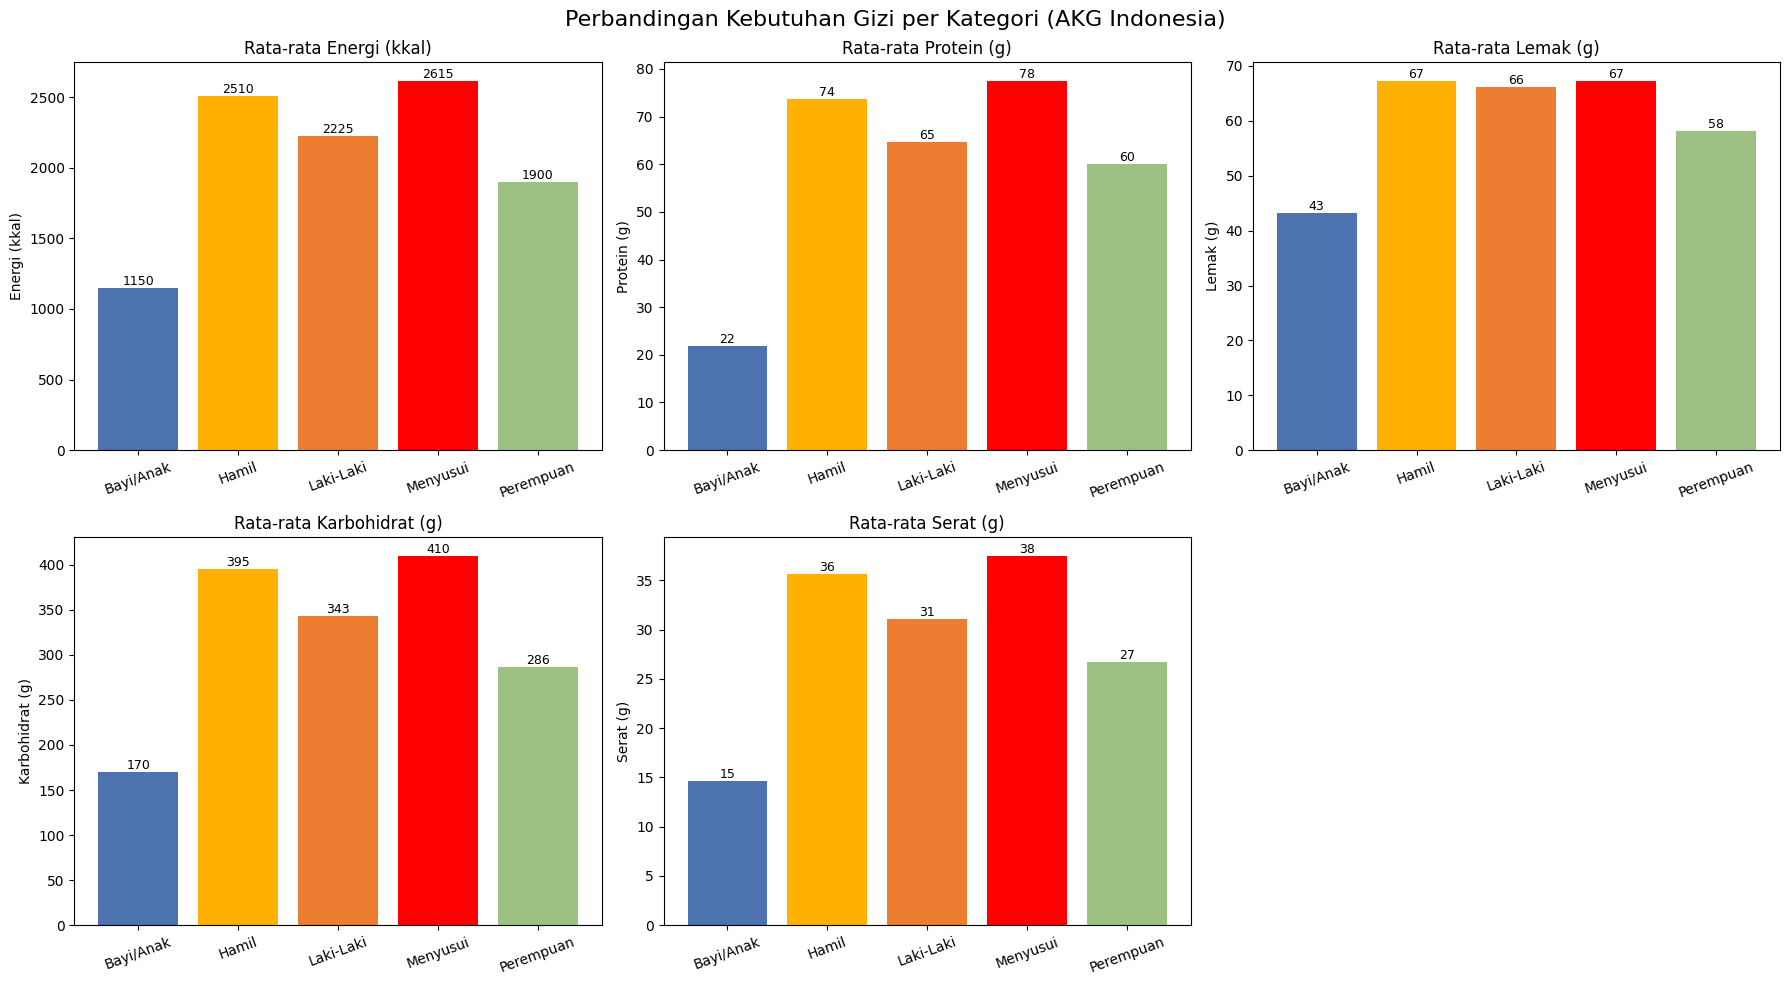

In [9]:
# Hitung rata-rata per kategori
avg = df.groupby('Kategori').mean(numeric_only=True)

# Ambil kategori
kategori = avg.index.tolist()

# Data masing-masing nutrisi
energi = avg['Energi (kkal)']
protein = avg['Protein (g)']
lemak = avg['Lemak (g)']
karbo = avg['Karbohidrat (g)']
serat = avg['Serat (g)']

# Warna (biar konsisten seperti contoh)
colors = ['#4C72B0', '#FFB000', '#ED7D31', '#FF0000', '#9DC183']

# Buat figure
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Perbandingan Kebutuhan Gizi per Kategori (AKG Indonesia)', fontsize=16)

def barplot(ax, data, title, ylabel):
    bars = ax.bar(kategori, data, color=colors)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.tick_params(axis='x', rotation=20)

    # Tambahkan label angka di atas bar
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height,
                f'{round(height)}',
                ha='center', va='bottom', fontsize=9)

# Plot masing-masing
barplot(axes[0, 0], energi, 'Rata-rata Energi (kkal)', 'Energi (kkal)')
barplot(axes[0, 1], protein, 'Rata-rata Protein (g)', 'Protein (g)')
barplot(axes[0, 2], lemak, 'Rata-rata Lemak (g)', 'Lemak (g)')
barplot(axes[1, 0], karbo, 'Rata-rata Karbohidrat (g)', 'Karbohidrat (g)')
barplot(axes[1, 1], serat, 'Rata-rata Serat (g)', 'Serat (g)')

# Kosongkan subplot terakhir (biar layout rapi)
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

Analisis 2

Heatmap Kebutuhan Gizi per Kelompok Usia dan Kondisi

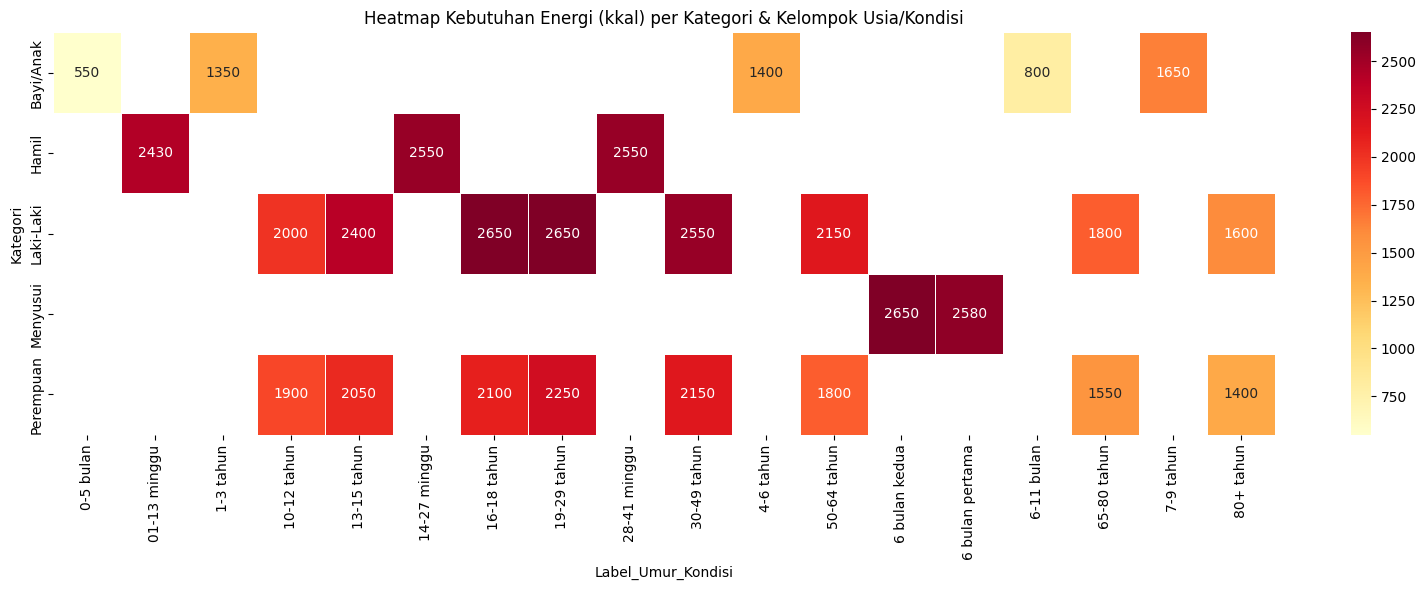

In [10]:
# Pivot table untuk heatmap
pivot = df.pivot_table(
    index='Kategori',
    columns='Label_Umur_Kondisi',
    values='Energi (kkal)',
    aggfunc='mean'
)

plt.figure(figsize=(16, 6))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=0.5)
plt.title('Heatmap Kebutuhan Energi (kkal) per Kategori & Kelompok Usia/Kondisi')
plt.tight_layout()
plt.savefig('heatmap_akg_energi.png')
plt.show()

Analisis 3

Identifikasi Kebutuhan Tertinggi & Terendah

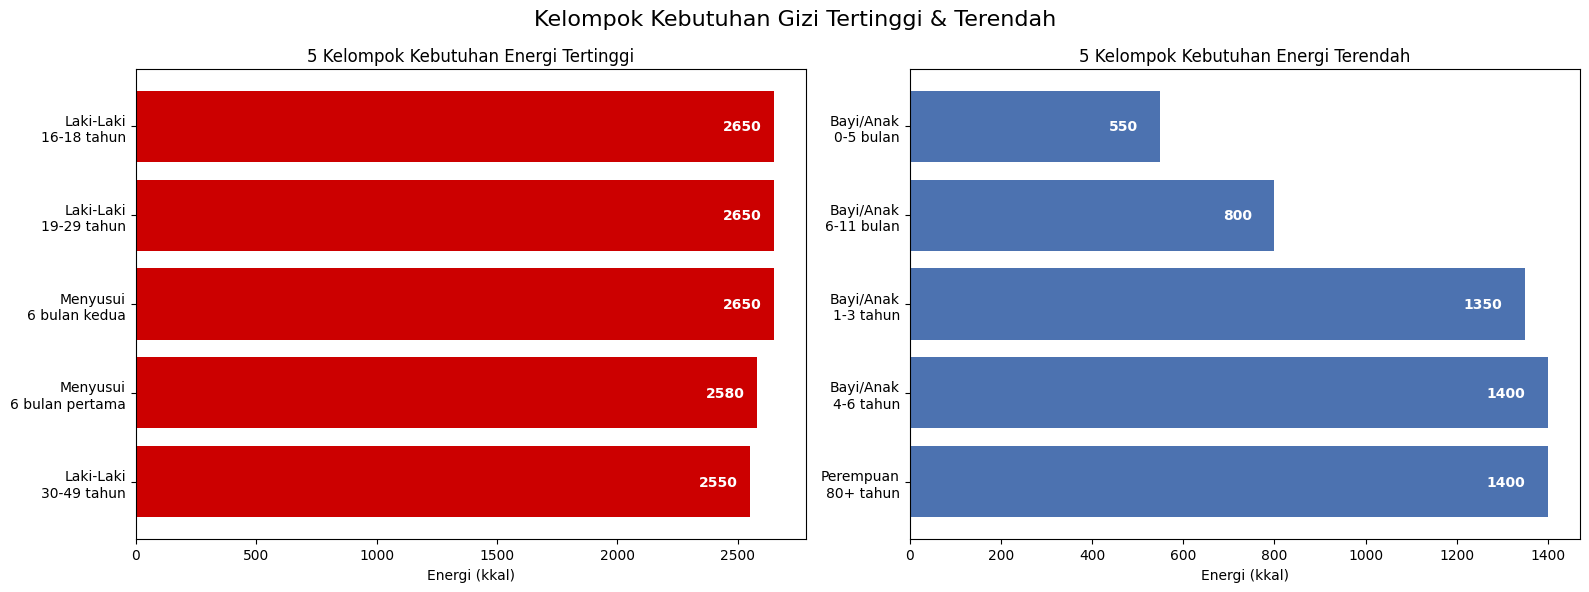

In [11]:
import matplotlib.pyplot as plt

# Buat label gabungan (biar seperti di gambar)
df['Group'] = df['Kategori'] + '\n' + df['Label_Umur_Kondisi']

# Ambil top 5 tertinggi & terendah berdasarkan energi
top5 = df.sort_values(by='Energi (kkal)', ascending=False).head(5)
bottom5 = df.sort_values(by='Energi (kkal)', ascending=True).head(5)

# Balik urutan untuk tampilan horizontal (biar yang terbesar di atas)
top5 = top5[::-1]
bottom5 = bottom5[::-1]

# Buat figure
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Kelompok Kebutuhan Gizi Tertinggi & Terendah', fontsize=16)

# ======================
# TOP 5 (KIRI)
# ======================
axes[0].barh(top5['Group'], top5['Energi (kkal)'], color='#cc0000')
axes[0].set_title('5 Kelompok Kebutuhan Energi Tertinggi')
axes[0].set_xlabel('Energi (kkal)')

# Label angka
for i, v in enumerate(top5['Energi (kkal)']):
    axes[0].text(v - 50, i, str(v), va='center', ha='right', color='white', fontweight='bold')

# ======================
# BOTTOM 5 (KANAN)
# ======================
axes[1].barh(bottom5['Group'], bottom5['Energi (kkal)'], color='#4C72B0')
axes[1].set_title('5 Kelompok Kebutuhan Energi Terendah')
axes[1].set_xlabel('Energi (kkal)')

# Label angka
for i, v in enumerate(bottom5['Energi (kkal)']):
    axes[1].text(v - 50, i, str(v), va='center', ha='right', color='white', fontweight='bold')

plt.tight_layout()
plt.show()

Analisis 4
Simulasi Pemenuhan AKG

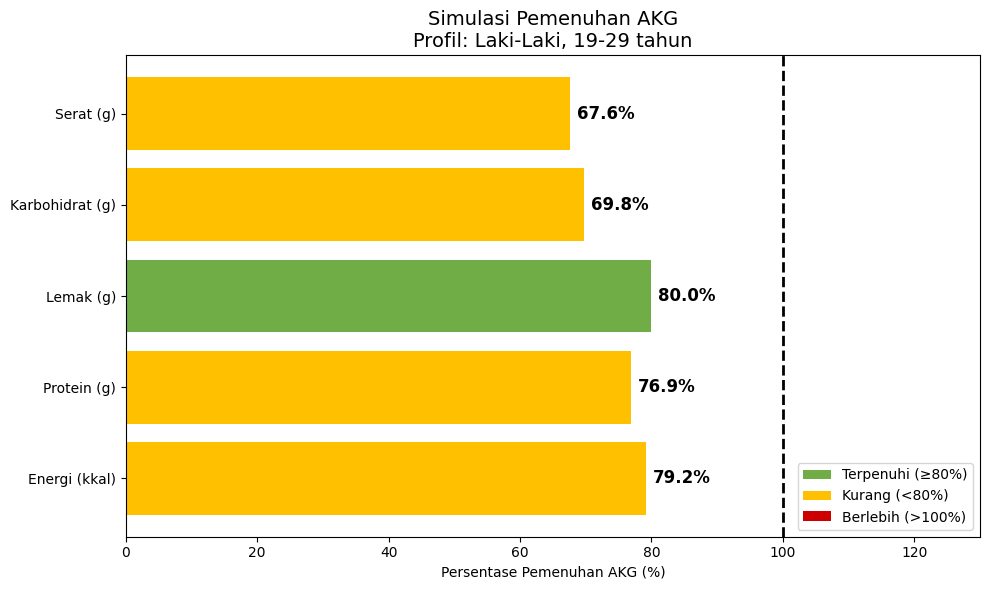

In [12]:
import matplotlib.pyplot as plt

# =========================
# DATA SIMULASI
# =========================
nutrisi = ['Energi (kkal)', 'Protein (g)', 'Lemak (g)', 'Karbohidrat (g)', 'Serat (g)']
persentase = [79.2, 76.9, 80.0, 69.8, 67.6]

# =========================
# WARNA BERDASARKAN KONDISI
# =========================
colors = []
for p in persentase:
    if p >= 100:
        colors.append('#cc0000')  # merah (berlebih)
    elif p >= 80:
        colors.append('#70AD47')  # hijau (terpenuhi)
    else:
        colors.append('#FFC000')  # kuning (kurang)

# =========================
# PLOT
# =========================
plt.figure(figsize=(10, 6))

bars = plt.barh(nutrisi, persentase, color=colors)

# Garis batas 100%
plt.axvline(x=100, color='black', linestyle='--', linewidth=2)

# Label persentase
for bar, val in zip(bars, persentase):
    plt.text(val + 1, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%',
             va='center', fontsize=12, fontweight='bold')

# Judul & label
plt.title('Simulasi Pemenuhan AKG\nProfil: Laki-Laki, 19-29 tahun', fontsize=14)
plt.xlabel('Persentase Pemenuhan AKG (%)')

# Legend manual
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#70AD47', label='Terpenuhi (≥80%)'),
    Patch(facecolor='#FFC000', label='Kurang (<80%)'),
    Patch(facecolor='#cc0000', label='Berlebih (>100%)')
]
plt.legend(handles=legend_elements, loc='lower right')

plt.xlim(0, 130)
plt.tight_layout()
plt.show()

In [14]:
# Simpan dataset AKG ke format CSV
df.to_csv('dataset_akg_final.csv', index=False)